<a href="https://colab.research.google.com/github/singleA4anchal/project/blob/main/probability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#1a. Tossing a coin 10,000 times
trials = 10000
coin_results = [random.choice(['H', 'T']) for _ in range(trials)]
p_heads = coin_results.count('H') / trials
p_tails = coin_results.count('T') / trials
print("Coin Toss (10,000 trials):", (p_heads, p_tails))

Coin Toss (10,000 trials): (0.5013, 0.4987)


In [3]:
#1b. Rolling two dice, probability of sum = 7
dice_trials = 10000
dice_results = [random.randint(1,6) + random.randint(1,6) for _ in range(dice_trials)]
p_sum_7 = dice_results.count(7) / dice_trials
print("Two Dice (sum=7):", p_sum_7)


Two Dice (sum=7): 0.1645


In [4]:
#2. Probability of at least one "6" in 10 rolls
def prob_at_least_one_six(trials=10000, rolls=10):
    success = 0
    for _ in range(trials):
        outcomes = [random.randint(1,6) for _ in range(rolls)]
        if 6 in outcomes:
            success += 1
    return success / trials

print("At least one '6' in 10 rolls:", prob_at_least_one_six())


At least one '6' in 10 rolls: 0.847


In [5]:
#3. Conditional Probability and Bayes’ Theorem
colors = ['R']*5 + ['G']*7 + ['B']*8
draws = [random.choice(colors) for _ in range(1000)]
conditional_count = 0
blue_count = 0
for i in range(1, len(draws)):
    if draws[i-1] == 'B':
        blue_count += 1
        if draws[i] == 'R':
            conditional_count += 1
p_red_given_blue = conditional_count / blue_count if blue_count > 0 else 0
print("P(Red | Previous Blue):", p_red_given_blue)


P(Red | Previous Blue): 0.23979591836734693


In [7]:


p_blue = draws.count('B') / len(draws)
p_red = draws.count('R') / len(draws)
p_blue_given_red = sum(1 for i in range(1, len(draws)) if draws[i-1] == 'R' and draws[i] == 'B') / draws.count('R')
bayes_lhs = p_red_given_blue
bayes_rhs = (p_blue_given_red * p_red) / p_blue if p_blue > 0 else 0
print("Bayes Check: LHS =", bayes_lhs, ", RHS =", bayes_rhs)


Bayes Check: LHS = 0.23979591836734693 , RHS = 0.22959183673469385


In [8]:
#4. Discrete Random Variable Simulation
X = np.random.choice([1,2,3], size=1000, p=[0.25,0.35,0.40])
print("Empirical Mean:", np.mean(X))
print("Empirical Variance:", np.var(X))
print("Empirical Std Dev:", np.std(X))



Empirical Mean: 2.158
Empirical Variance: 0.6350359999999999
Empirical Std Dev: 0.7968914606143047


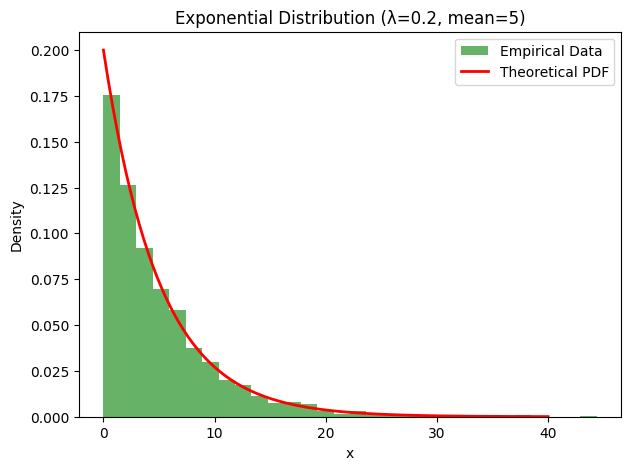

In [9]:

#5. Exponential Distribution Simulation
samples = np.random.exponential(scale=5, size=2000)
plt.figure(figsize=(7,5))
plt.hist(samples, bins=30, density=True, alpha=0.6, color='g', label="Empirical Data")
x_vals = np.linspace(0, 40, 200)
pdf = (1/5)*np.exp(-x_vals/5)
plt.plot(x_vals, pdf, 'r-', lw=2, label="Theoretical PDF")
plt.title("Exponential Distribution (λ=0.2, mean=5)")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()


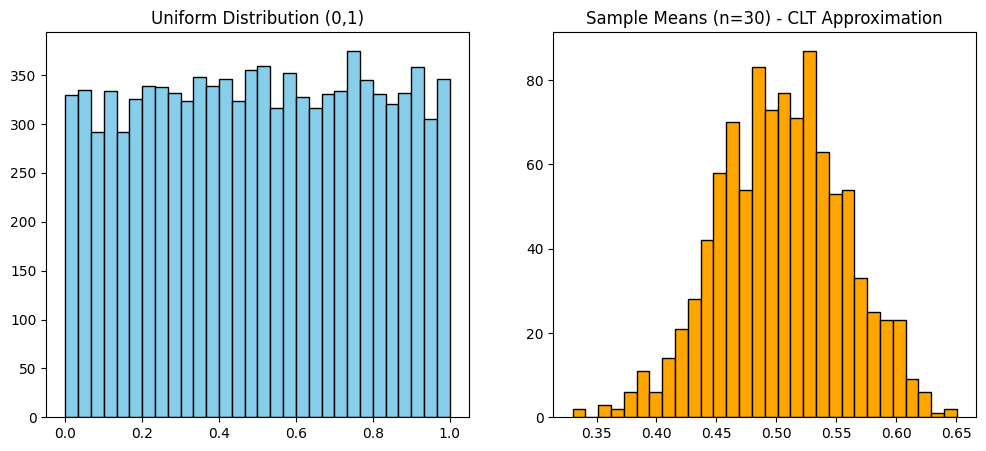

In [10]:
# 6. Central Limit Theorem Simulation
uniform_data = np.random.uniform(0,1,10000)
sample_means = [np.mean(np.random.choice(uniform_data, size=30)) for _ in range(1000)]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(uniform_data, bins=30, color='skyblue', edgecolor='black')
plt.title("Uniform Distribution (0,1)")
plt.subplot(1,2,2)
plt.hist(sample_means, bins=30, color='orange', edgecolor='black')
plt.title("Sample Means (n=30) - CLT Approximation")
plt.show()